# Exploratory Analysis of Digital Democracy and Social Media Activity (Poland Elections 2023)

This notebook explores patterns in social media posts related to the 2023 Polish elections.

We analyse:
- Actor activity
- Temporal posting patterns
- Text content signals
- Coordination indicators
- Potential information integrity signals

In [2]:
# Load imports
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

plt.style.use("ggplot")

In [ ]:
# Setup
BASE_DIR = Path(".")
DATA_PATH = BASE_DIR / "raw_social_media_sample.xlsx" 
OUTPUT_DIR = BASE_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True

OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "yellow": "#F0E442",
    "purple": "#CC79A7",
    "grey": "#999999",
}

In [6]:
# Load data
df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()

df.head()

,username,type of actor,date and time,post
0,Rzeczpospolita,Media Institutions,2023-07-18 10:35:10,The camera recorded the last seconds of the fl...
1,Szymon Hołownia,National Politicians,2023-07-19 06:57:41,The police humiliating the woman who took the ...
2,Gazeta Wyborcza,Media Institutions,2023-07-15 21:59:02,"The disease kills women with dozens, doctors h..."
3,Super Express,Media Institutions,2023-07-18 15:45:10,"The 22-year-old was sitting behind the wheel, ..."
4,Krzysztof Żuk,Regional Politicians,2023-07-18 12:41:15,This is an important day for Lublin's young pe...


In [7]:
# Inspect data
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   username       1000 non-null   str  
 1   type of actor  1000 non-null   str  
 2   date and time  1000 non-null   str  
 3   post           1000 non-null   str  
dtypes: str(4)
memory usage: 169.4 KB


,username,type of actor,date and time,post
count,1000,1000,1000,1000
unique,46,5,989,976
top,Onet,Media Institutions,2023-07-19 16:00:01,Okay.
freq,145,910,2,13


In [8]:
# Data preprocessing
df = df.rename(columns={
    "type of actor": "actor_type",
    "date and time": "datetime"
})

df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day_name"] = df["datetime"].dt.day_name()

days = [
    "Monday","Tuesday","Wednesday","Thursday",
    "Friday","Saturday","Sunday"
]

df["day_name"] = pd.Categorical(df["day_name"], categories=days, ordered=True)

In [9]:
# Quick checks
df.isnull().sum()
df["actor_type"].value_counts()

actor_type
Media Institutions      910
Regional Politicians     42
National Politicians     39
Journalists               8
Clergy                    1
Name: count, dtype: int64

In [10]:
# Top actors & activity overview
top_users = df["username"].value_counts().head(5)
actor_counts = df["actor_type"].value_counts()

top_users, actor_counts

(username
 Onet                145
 Wirtualna Polska    117
 Gazeta Wyborcza      92
 Super Express        77
 Radio ZET            69
 Name: count, dtype: int64,
 actor_type
 Media Institutions      910
 Regional Politicians     42
 National Politicians     39
 Journalists               8
 Clergy                    1
 Name: count, dtype: int64)

In [11]:
# Temporal patterns
posts_per_day = df["date"].value_counts().sort_index()
posts_per_hour = df["hour"].value_counts().sort_index()
posts_per_weekday = df.groupby("day_name", observed=False).size().reindex(days)

posts_per_day.idxmax(), posts_per_hour.idxmax()

(datetime.date(2023, 7, 14), np.int32(16))

In [12]:
# Actor × time heatmap data
actor_hour = (
    df.groupby(["actor_type", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

In [14]:
# Coordination detection
coordination = df.groupby("post").agg(
    n_users=("username", "nunique"),
    time_min=("datetime", "min"),
    time_max=("datetime", "max"),
)

coordination["time_span_minutes"] = (
    coordination["time_max"] - coordination["time_min"]
).dt.total_seconds() / 60

coordinated = coordination[
    (coordination["n_users"] > 1) &
    (coordination["time_span_minutes"] <= 60)
]

len(coordinated)

0

In [15]:
# Low-information content
df["is_low_info"] = (
    df["post"].str.lower().str.contains(
        r"\bokay\b|\bnote\b|\bnightmare\b",
        na=False
    )
)

low_info_actor_share = (
    df.groupby("actor_type")["is_low_info"]
    .mean()
    .sort_values(ascending=False)
)

low_info_actor_share

actor_type
Media Institutions      0.021978
Clergy                  0.000000
Journalists             0.000000
National Politicians    0.000000
Regional Politicians    0.000000
Name: is_low_info, dtype: float64

In [16]:
# Simple text analysis
def clean_words(text_series):
    text = " ".join(text_series).lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = text.split()
    return [
        w for w in words
        if w not in ENGLISH_STOP_WORDS and len(w) > 2
    ]

all_words = clean_words(df["post"])
word_counts = Counter(all_words)

word_counts.most_common(10)

[('poland', 56),
 ('tvrepublic', 52),
 ('turn', 51),
 ('people', 40),
 ('polish', 39),
 ('time', 39),
 ('new', 38),
 ('years', 37),
 ('like', 31),
 ('today', 28)]

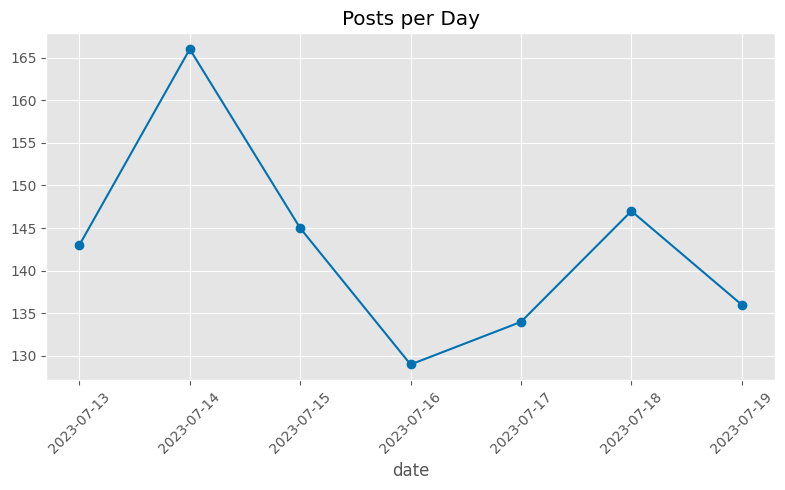

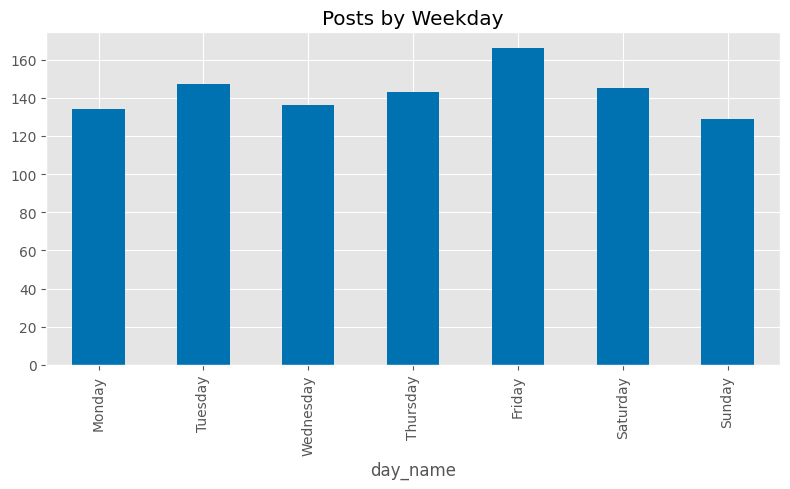

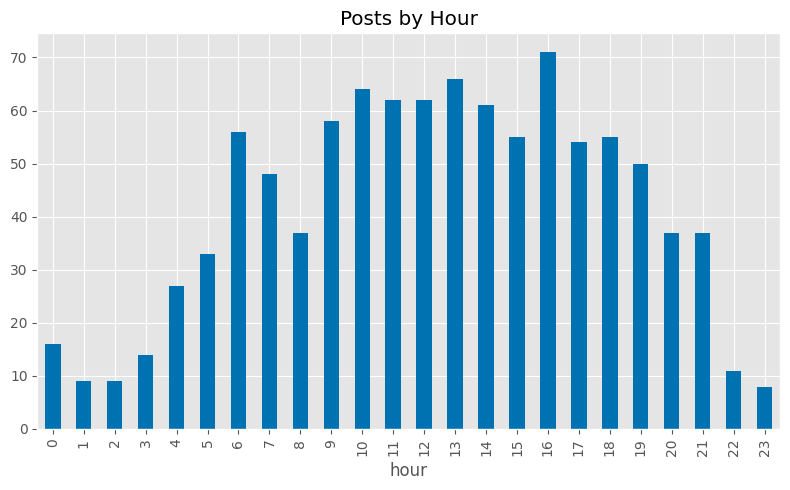

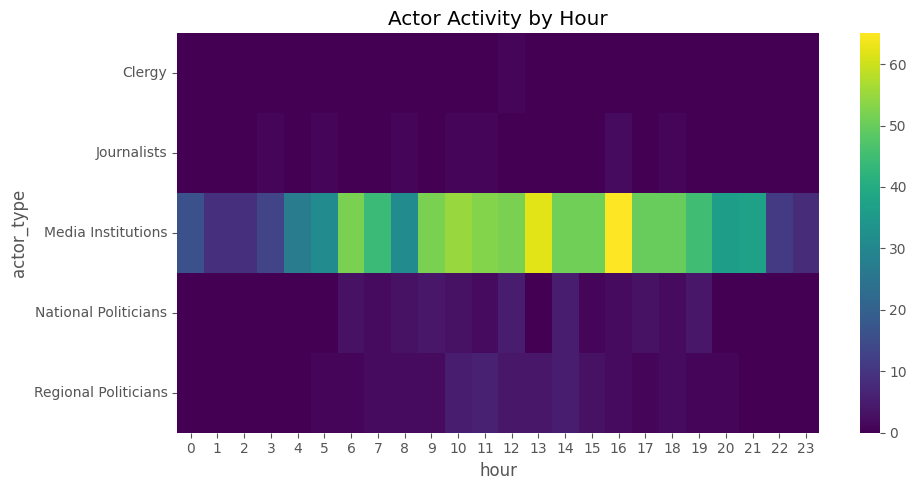

In [17]:
# Visualisations

BLUE = OKABE_ITO["blue"]

# Posts per day
plt.figure(figsize=(8,5))
posts_per_day.plot(marker="o", color=BLUE)
plt.title("Posts per Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Posts per weekday
plt.figure(figsize=(8,5))
posts_per_weekday.plot(kind="bar", color=BLUE)
plt.title("Posts by Weekday")
plt.tight_layout()
plt.show()

# Posts per hour
plt.figure(figsize=(8,5))
posts_per_hour.plot(kind="bar", color=BLUE)
plt.title("Posts by Hour")
plt.tight_layout()
plt.show()

# Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(actor_hour, cmap="viridis")
plt.title("Actor Activity by Hour")
plt.tight_layout()
plt.show()

## Key Findings

- Posting activity is highly concentrated among a small number of media actors.
- Clear diurnal pattern with peak activity during daytime hours.
- Limited evidence of exact-text coordination.
- Actor types differ strongly in volume but less in timing patterns.
- Content is largely institutional and repetitive in structure.